In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('creditcard.csv')

# Display first few rows
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
from sklearn.preprocessing import StandardScaler

# Drop time column and scale 'Amount'
df = df.drop(['Time'], axis=1)
df['Amount'] = StandardScaler().fit_transform(df[['Amount']])

# Sample a subset for better visualization (optional)
df_sampled = df.sample(n=10000, random_state=42).reset_index(drop=True)


In [3]:
from sklearn.neighbors import LocalOutlierFactor

# Separate features and labels
X = df_sampled.drop('Class', axis=1)
y_true = df_sampled['Class']

# Apply LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
y_pred = lof.fit_predict(X)

# Outliers are labeled as -1
df_sampled['LOF_Pred'] = y_pred
df_sampled['Anomaly_Score'] = lof.negative_outlier_factor_


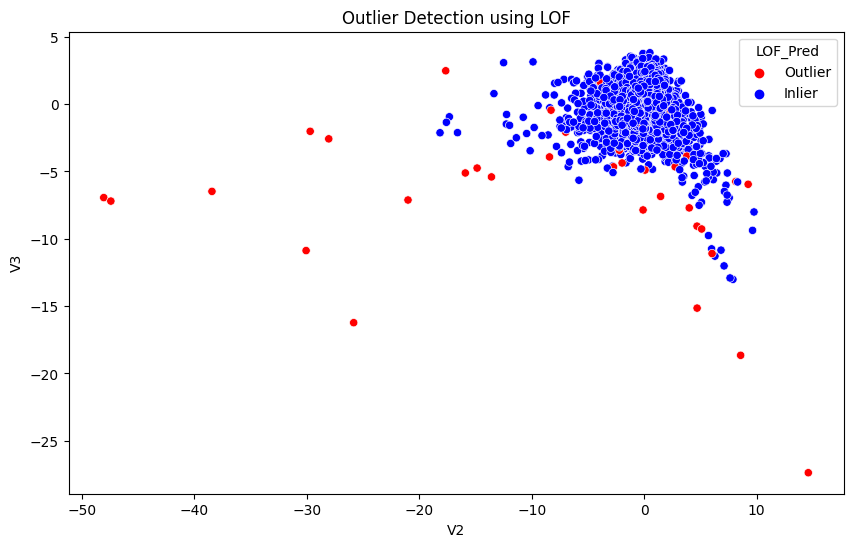

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='V2', y='V3', 
    data=df_sampled, 
    hue=df_sampled['LOF_Pred'].map({1: 'Inlier', -1: 'Outlier'}), 
    palette=['red', 'blue']
)
plt.title("Outlier Detection using LOF")
plt.show()


/Users/parz/miniforge3/envs/data-science/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/parz/miniforge3/envs/data-science/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/parz/miniforge3/envs/data-science/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/parz/miniforge3/envs/data-science/lib/python3.9/site-packages/seaborn/

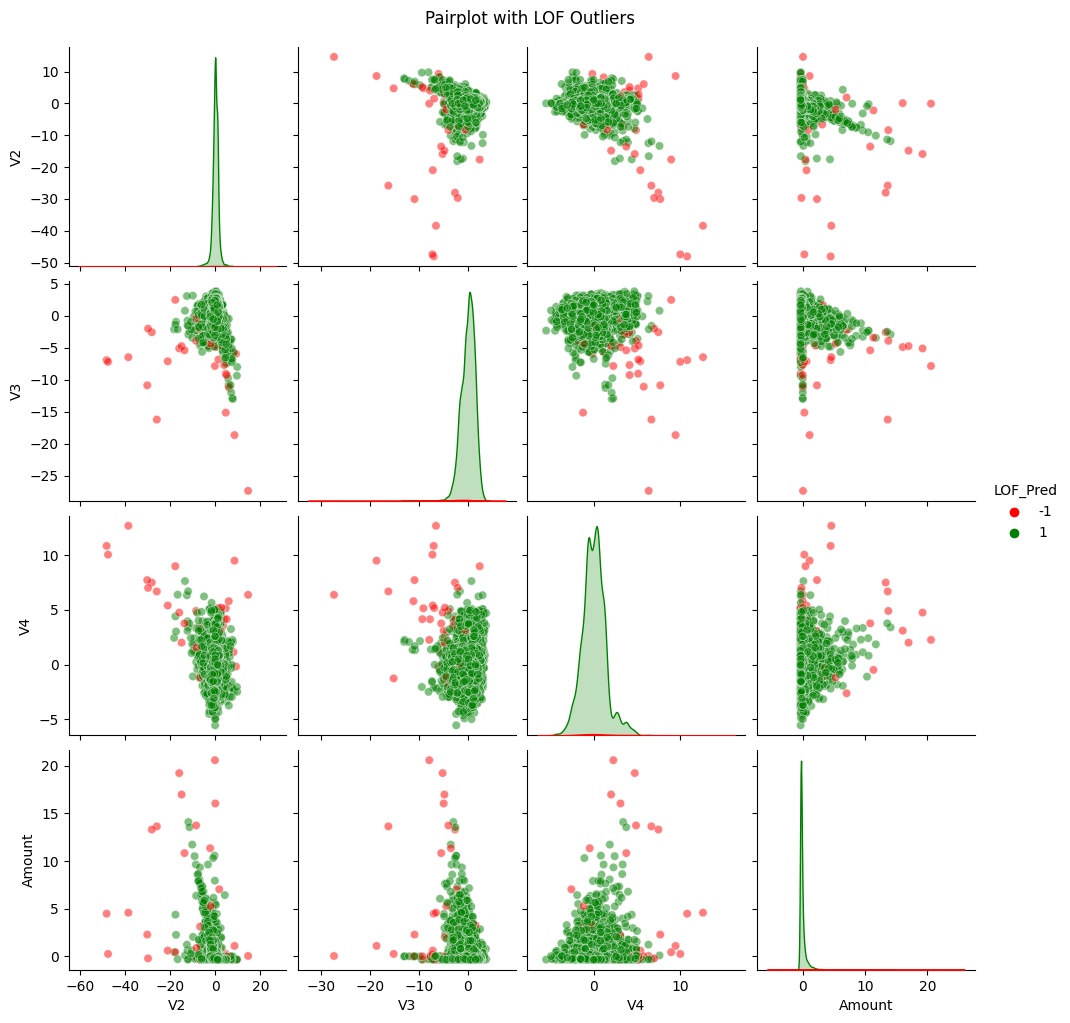

In [5]:
sns.pairplot(df_sampled[['V2', 'V3', 'V4', 'Amount', 'LOF_Pred']], 
             hue='LOF_Pred', 
             palette={1: 'green', -1: 'red'}, 
             plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot with LOF Outliers', y=1.02)
plt.show()


In [6]:
# Sort by anomaly score (lower = more anomalous)
outliers = df_sampled[df_sampled['LOF_Pred'] == -1]
outliers_sorted = outliers.sort_values(by='Anomaly_Score')

print("Top 5 Outliers by LOF Score:")
print(outliers_sorted[['Amount', 'Anomaly_Score']].head())


Top 5 Outliers by LOF Score:
        Amount  Anomaly_Score
7846 -0.016271      -3.805065
4640 -0.333239      -3.759374
6706  0.006558      -3.523116
1384  4.484455      -3.406560
5100  0.046539      -3.369178


In [7]:
from sklearn.svm import OneClassSVM

ocsvm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.01)
y_ocsvm = ocsvm.fit_predict(X)


In [8]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.01, random_state=42)
y_iso = iso_forest.fit_predict(X)


/Users/parz/miniforge3/envs/data-science/lib/python3.9/site-packages/sklearn/base.py:420: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


In [9]:
print("LOF Outliers:", (y_pred == -1).sum())
print("Isolation Forest Outliers:", (y_iso == -1).sum())
print("One-Class SVM Outliers:", (y_ocsvm == -1).sum())


LOF Outliers: 100
Isolation Forest Outliers: 100
One-Class SVM Outliers: 196


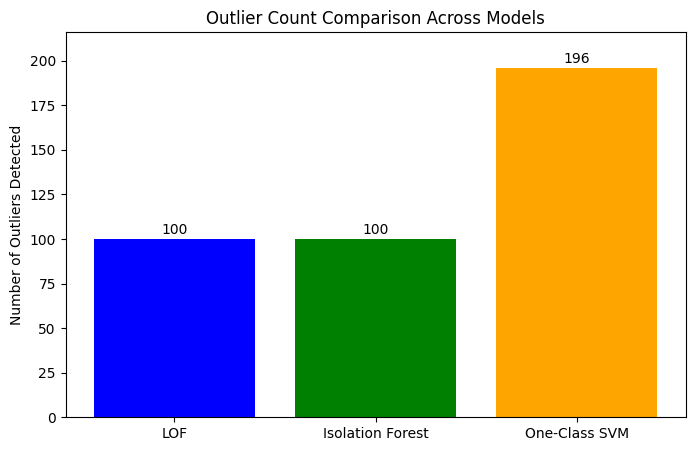

In [11]:
# Outlier counts from different models (hypothetical numbers for illustration; in practice, these should come from actual model outputs)
lof_outliers = 100
iso_outliers = 100
ocsvm_outliers = 196

# Labels and values
models = ['LOF', 'Isolation Forest', 'One-Class SVM']
outlier_counts = [lof_outliers, iso_outliers, ocsvm_outliers]

# Plotting
plt.figure(figsize=(8, 5))
bars = plt.bar(models, outlier_counts, color=['blue', 'green', 'orange'])
plt.title('Outlier Count Comparison Across Models')
plt.ylabel('Number of Outliers Detected')

# Annotate bars with values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, int(yval), ha='center', va='bottom')

plt.ylim(0, max(outlier_counts) + 20)
plt.show()
